In [52]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import pandas as pd
import glob
import os
import xarray as xr
import rasterio as rio
from rasterio.mask import mask
from shapely.geometry import mapping
import geopandas as gpd

# Process the field data from 2020 Grand Mesa campaign

In [47]:
folder = '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/field_data/'
os.listdir(folder)

['GrandMesa_boundary_UTM.prj',
 'Lidar_bcal_processed',
 'SNEX20_GM_SWE_SD_Lidar-GPR_20200201_v01.0.csv',
 'SNEX20_GM_SWE_SD_SnowDensity_20200201_v01.0.tif',
 '.DS_Store',
 'depth',
 'SNEX20_GM_Lidar_SD_20200201_20200202_v01.0.tif',
 'SnowEx20_SnowPits_GMIOP_Summary_Environment_2020_v01.csv',
 'SnowEx2020_SnowDepths_COGM_alldepths_v01_handmeasurements.csv',
 'density',
 'GrandMesa_WGS.prj',
 'GrandMesa_boundary_UTM.shp',
 'GrandMesa_WGS.dbf',
 'SNEX20_GIS_REF_GM_v01',
 'GrandMesa_boundary_UTM.shx',
 'GrandMesa_boundary_UTM.qmd',
 'Tate_results',
 'SNEX20_GM_SWE_SD_SWE_20200201_v01.0.tif',
 'SnowEx20_SnowPits_GMIOP_Summary_SWE_2020_v01.csv',
 'meterology',
 'SNEX20_GM_Lidar_SDsubset_20200201_20200202_v01.0.tif',
 'GrandMesa_WGS.qmd',
 'GrandMesa_WGS.shx',
 'GrandMesa_boundary_UTM.dbf',
 'GrandMesa_WGS.cpg',
 'GrandMesa_WGS.shp']

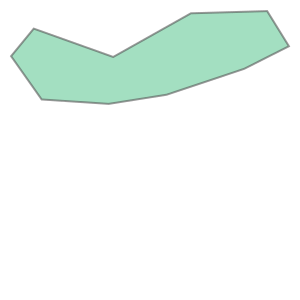

In [57]:
# read site shapefile with geopandas
site_gdf = gpd.read_file(folder+'GrandMesa_boundary_UTM.shp')
geoms = site_gdf.geometry.values
geom = geoms[0]
# site_gdf
geom

## 1) Calculate velocity from density

In [22]:
# list density files
os.listdir(folder+'density/')

['SNEX20_GM_SWE_SD_Lidar-GPR_20200201_v01.0.csv',
 'SNEX20_GM_SWE_SD_SnowDensity_20200201_v01.0.tif',
 'SnowEx20_SnowPits_GMIOP_Summary_SWE_2020_v01.csv']

(3500, 4501)


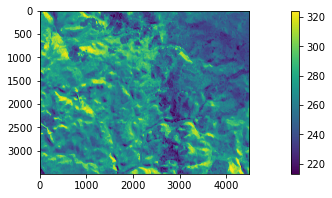

In [60]:
# read in density raster 
density_snex_r = rio.open(folder+'density/SNEX20_GM_SWE_SD_SnowDensity_20200201_v01.0.tif')
density_snex = density_snex_r.read(1)
density_snex[density_snex < 0] = np.NaN # all negative numbers are not real values 
print(density_snex.shape)

# # crop to site shapefile - unnecessary, it's a small region fully inside site bounds
# out_image, out_transform = mask(density_snex_r, [mapping(geom)], crop=True)
# crop_array = out_image[0,:,:]
# crop_array[crop_array < -1e3] = np.NaN

# plot
fig, ax = plt.subplots(figsize=(15,3)); 
plt.imshow(density_snex)
# plt.imshow(crop_array)
plt.colorbar(); ax.set_facecolor('black'); plt.show()

In [43]:
# read in density CSV
density_df = pd.read_csv(folder+'density/SNEX20_GM_SWE_SD_Lidar-GPR_20200201_v01.0.csv')
measured_densities = density_df['Density (kg/m3)']
# density_df = pd.read_csv(folder+'density/SnowEx20_SnowPits_GMIOP_Summary_SWE_2020_v01.csv')
# measured_densities = density_df['Density Mean (kg/m^3)']
density_df.head()

,Index,X (WGS84 UTM 12N),Y (WGS84 UTM 12N),TWT (ns),Depth (cm),Density (kg/m3),SWE (mm),Velocity (m/ns),Permittivity
0,1167683,741832.069571,4.322818e+06,6.3,77.998048,240.714051,187.752261,0.249129,1.450087
1,1167684,741832.069571,4.322817e+06,6.0,74.189454,242.537355,179.937140,0.248810,1.453802
2,1167685,741832.069571,4.322816e+06,7.2,89.008790,242.836446,216.145783,0.248758,1.454412
3,1167686,741832.069571,4.322815e+06,7.0,86.518556,243.131157,210.353566,0.248707,1.455013
4,1167687,741832.069571,4.322814e+06,5.5,67.890626,244.996712,166.329802,0.248382,1.458821


In [44]:
# calculate the density 
calculated_density = np.array(measured_densities) # CSV file
# calculated_density = density_snex.flatten() # raster data

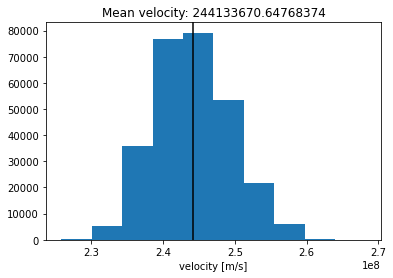

In [45]:
# from density, calculate the radar wave velocity using e_snowdry equation
calculated_velocity = np.sqrt((3e8**2)/(1+(1.7*calculated_density/1000) + (0.7*(calculated_density/1000)**2)))

# plot and show mean
plt.hist(calculated_velocity,bins=10)
plt.title('Mean velocity: '+str(np.nanmean(calculated_velocity)));
plt.axvline(x=np.nanmean(calculated_velocity),color='k')
plt.xlabel('velocity [m/s]')
plt.show()

## 2) Compare lidar depth maps

In [21]:
# list depth files
os.listdir(folder+'depth/')

['SNEX20_GM_Lidar_SD_20200201_20200202_v01.0.tif.aux.xml',
 'SNEX20_GM_SWE_SD_Lidar-GPR_20200201_v01.0.csv',
 'SNEX20_GM_Lidar_SD_20200201_20200202_v01.0_UTM12.tif.aux.xml',
 'SNEX20_GM_Lidar_SD_20200201_20200202_v01.0.tif',
 'SnwDpth_Grnd_Asp_Slp_CPC_CHM_FHD512.tif',
 'SnowEx2020_SnowDepths_COGM_alldepths_v01_handmeasurements.csv',
 'SnowEx20_SnowPits_GMIOP_Summary_SWE_2020_v01.csv',
 'SNEX20_GM_Lidar_SD_20200201_20200202_v01.0_UTM12.tif',
 'SnwDpth_Grnd_Asp_Slp_CPC_CHM_FHD512.tif.aux.xml']

(3501, 17004)


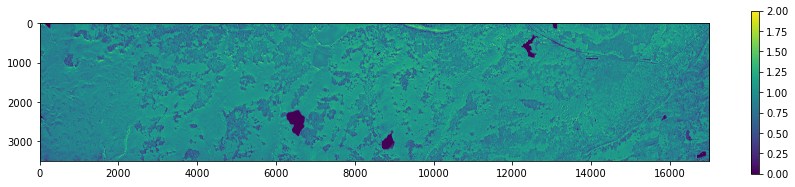

In [6]:
lidar_snex_r = rio.open(folder+'depth/SNEX20_GM_Lidar_SD_20200201_20200202_v01.0_UTM12.tif')
lidar_snex = lidar_snex_r.read(1)
lidar_snex[lidar_snex < 0] = np.NaN # all negative numbers are not real values 
print(lidar_snex.shape)
fig, ax = plt.subplots(figsize=(15,3)); plt.imshow(lidar_snex,vmin=0,vmax=2); # plot
plt.colorbar(); ax.set_facecolor('black'); plt.show()

In [73]:
lidar_snex_crop = lidar_snex[:3500,4:]
lidar_snex_crop.shape

(3500, 17000)

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


(3500, 17000)


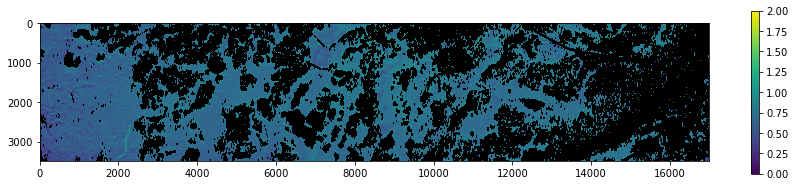

In [66]:
lidar_bcal_r = rio.open(folder+'depth/SnwDpth_Grnd_Asp_Slp_CPC_CHM_FHD512.tif')
lidar_bcal = lidar_bcal_r.read(1) # first band is snow depth
lidar_bcal[lidar_bcal < 0] = np.NaN
print(lidar_bcal.shape)

fig, ax = plt.subplots(figsize=(15,3)); plt.imshow(lidar_bcal,vmin=0,vmax=2); 
plt.colorbar(); ax.set_facecolor('black'); plt.show()

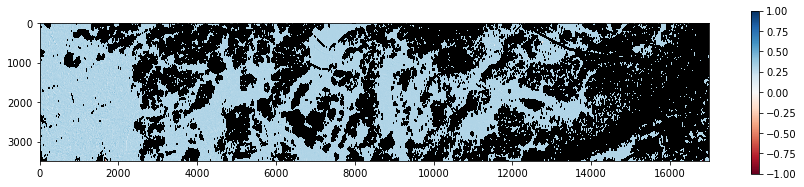

In [74]:
fig, ax = plt.subplots(figsize=(15,3)); plt.imshow(lidar_snex_crop - lidar_bcal, cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar(); ax.set_facecolor('black'); plt.show()

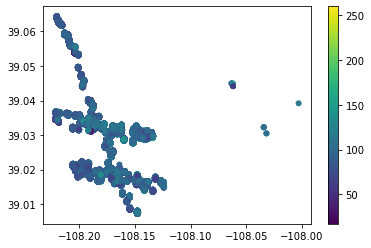

In [77]:
# grab other depth data
depth_df = pd.read_csv(folder+'depth/SnowEx2020_SnowDepths_COGM_alldepths_v01_handmeasurements.csv')
plt.scatter(depth_df.Longitude,depth_df.Latitude,c=depth_df['Depth (cm)'],s=25)
plt.colorbar(); plt.show()

In [ ]:
# write code to compare pt & gridded data - rasterio.show()